## Chronic Kidney Disease- Exploratory Data Analysis
**Dataset:** UCI Chronic Kidney Disease Dataset (400 patients, 25 clinical features)  
**Objective:** Understand clinical patterns that differentiate CKD patients from non-CKD patients, identify key risk indicators, and prepare data for downstream classification modelling.

---


In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')


### Loading data


In [21]:
DATA_PATH = os.path.join(os.getcwd(), "kidney_disease.csv")
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (400, 26)


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


### Description

| **Feature** | **Full Name** | **Type** |
|---|---|---|
| age | Age | Numerical |
| bp | Blood Pressure (mm/Hg) | Numerical |
| sg | Specific Gravity | Numerical |
| al | Albumin (0–5) | Numerical |
| su | Sugar (0–5) | Numerical |
| rbc | Red Blood Cells | Categorical |
| pc | Pus Cell | Categorical |
| pcc | Pus Cell Clumps | Categorical |
| ba | Bacteria | Categorical |
| bgr | Blood Glucose Random (mgs/dl) | Numerical |
| bu | Blood Urea (mgs/dl) | Numerical |
| sc | Serum Creatinine (mgs/dl) | Numerical |
| sod | Sodium (mEq/L) | Numerical |
| pot | Potassium (mEq/L) | Numerical |
| hemo | Haemoglobin (gms) | Numerical |
| pcv | Packed Cell Volume | Numerical |
| wc | White Blood Cell Count (cells/cumm) | Numerical |
| rc | Red Blood Cell Count (millions/cmm) | Numerical |
| htn | Hypertension | Categorical |
| dm | Diabetes Mellitus | Categorical |
| cad | Coronary Artery Disease | Categorical |
| appet | Appetite | Categorical |
| pe | Pedal Edema | Categorical |
| ane | Anaemia | Categorical |
| classification | CKD / Not CKD (Target) | Binary |


In [22]:
df.shape


(400, 26)

In [23]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    
 9   ba              396 non-null    str    
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    str    
 17  wc              295 non-null    str    
 18  r

In [24]:
df.describe()


,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


### Data Cleaning
**Cleaning must happen before any analysis or visualisation.** This section handles:
- Dropping irrelevant columns
- Renaming columns for readability
- Fixing dirty values (tab characters, `?` placeholders)
- Converting mistyped columns to correct dtypes
- Encoding the target variable


In [25]:
# Drop ID because it carries no analytical value

df.drop('id', axis = 1, inplace = True)


In [26]:
# Rename all columns to readable full names
df.columns = [
    'age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
    'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
    'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
    'potassium', 'haemoglobin', 'packed_cell_volume',
    'white_blood_cell_count', 'red_blood_cell_count',
    'hypertension', 'diabetes_mellitus', 'coronary_artery_disease',
    'appetite', 'pedal_edema', 'anaemia', 'class'
]
print("Columns renamed successfully.")
print(df.columns.tolist())


Columns renamed successfully.
['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium', 'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count', 'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'pedal_edema', 'anaemia', 'class']


In [27]:
# These 3 columns loaded as text — convert to numeric
df['packed_cell_volume'] = pd.to_numeric(df['packed_cell_volume'], errors = 'coerce')
df['white_blood_cell_count'] = pd.to_numeric(df['white_blood_cell_count'], errors = 'coerce')
df['red_blood_cell_count'] = pd.to_numeric(df['red_blood_cell_count'], errors = 'coerce')


In [28]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object' and col != 'class']

for col in cat_cols:
    print(f"{col} has {df[col].unique()} values \n")


In [29]:
# Fix tab characters and whitespace in categorical columns

df['diabetes_mellitus'].replace(to_replace = {' yes':'yes', '\tyes': 'yes', '\tno': 'no'}, inplace = True)

df['coronary_artery_disease'] = df['coronary_artery_disease'].replace(to_replace = '\tno', value = 'no')

df['class'] = df['class'].replace(to_replace = 'ckd\t', value = 'ckd')

print("Dirty values fixed.")


Dirty values fixed.


In [30]:
df['class'] = df['class'].map({'ckd': 0, 'notckd': 1})

print(df['class'].value_counts())
print(f"CKD patients    : {(df['class']==0).sum()} ({(df['class']==0).mean()*100:.1f}%)")
print(f"Non-CKD patients: {(df['class']==1).sum()} ({(df['class']==1).mean()*100:.1f}%)")


class
0    250
1    150
Name: count, dtype: int64
CKD patients    : 250 (62.5%)
Non-CKD patients: 150 (37.5%)


In [31]:
# Null value assessment BEFORE imputation
null_counts = df.isnull().sum().sort_values(ascending=False)
null_pct = (null_counts / len(df) * 100).round(1)

null_summary = pd.DataFrame({'Missing Count': null_counts, 'Missing %': null_pct})
null_summary = null_summary[null_summary['Missing Count'] > 0]
print(null_summary.to_string())


                         Missing Count  Missing %
red_blood_cells                    152       38.0
red_blood_cell_count               131       32.8
white_blood_cell_count             106       26.5
potassium                           88       22.0
sodium                              87       21.8
packed_cell_volume                  71       17.8
pus_cell                            65       16.2
haemoglobin                         52       13.0
sugar                               49       12.2
specific_gravity                    47       11.8
albumin                             46       11.5
blood_glucose_random                44       11.0
blood_urea                          19        4.8
serum_creatinine                    17        4.2
blood_pressure                      12        3.0
age                                  9        2.2
pus_cell_clumps                      4        1.0
bacteria                             4        1.0
hypertension                         2        0.5


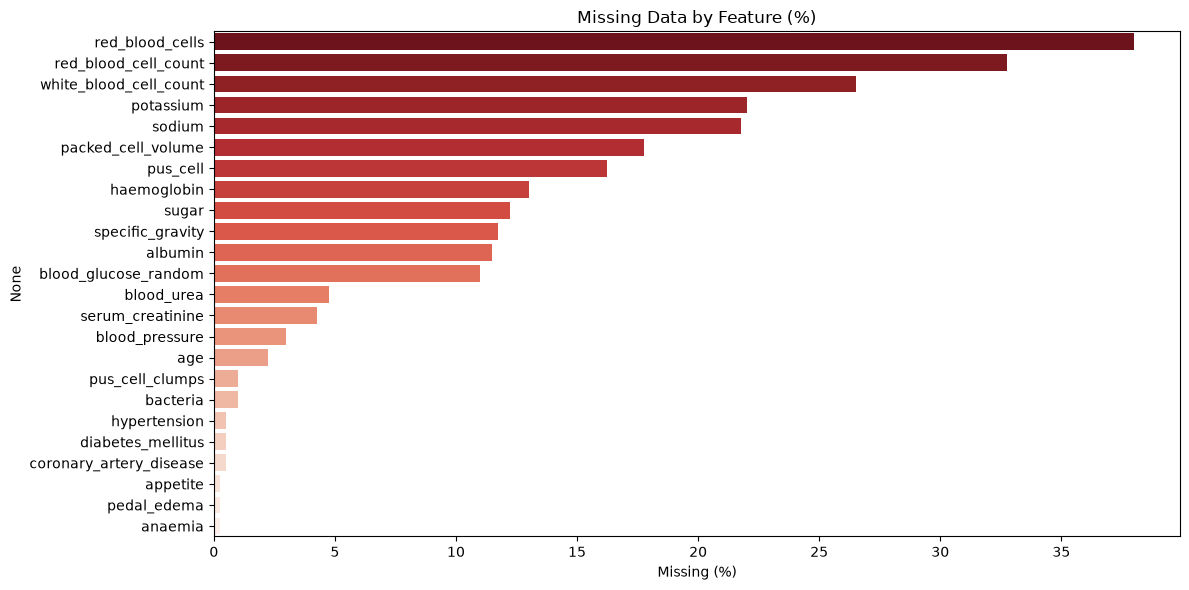

In [32]:
# Visualise missing data
plt.figure(figsize=(12, 6))

missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='Reds_r')

plt.title('Missing Data by Feature (%)')
plt.xlabel('Missing (%)')

plt.tight_layout()
plt.show()

### **Observation- Missing Data:**
- `red_blood_cell_count` (33%), `white_blood_cell_count` (26%), and `packed_cell_volume` (18%) have the highest missing values among numerical features.
- Several categorical features (e.g., `red_blood_cells`, `pus_cell`) have substantial missing rates and these are imputed using mode.
- High missingness is common in clinical datasets where tests were not ordered for all patients. Median/mode imputation is used to retain all 400 records rather than dropping rows.


In [33]:
# Impute numerical columns with median, categorical columns with mode
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

median_values = df[num_cols].median()
df[num_cols] = df[num_cols].fillna(median_values)

mode_values = df[cat_cols].mode().iloc[0]
df[cat_cols] = df[cat_cols].fillna(mode_values)

print("Nulls remaining after imputation:", df.isnull().sum().sum())


Nulls remaining after imputation: 0


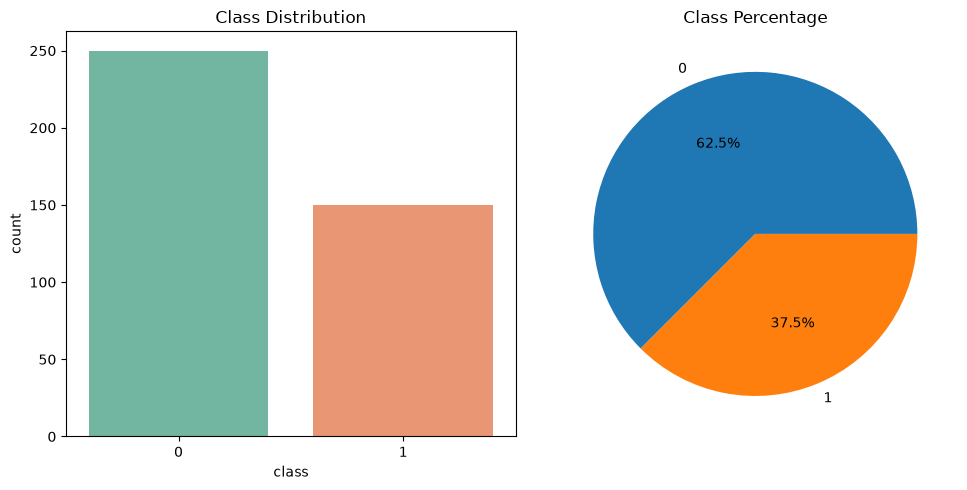

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))

# Bar Chart
sns.countplot(data=df, x='class', palette='Set2', ax=ax[0])
ax[0].set_title('Class Distribution')

# Pie Chart
df['class'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=ax[1]
)
ax[1].set_ylabel('')
ax[1].set_title('Class Percentage')

plt.tight_layout()
plt.show()


### Univariate Analysis


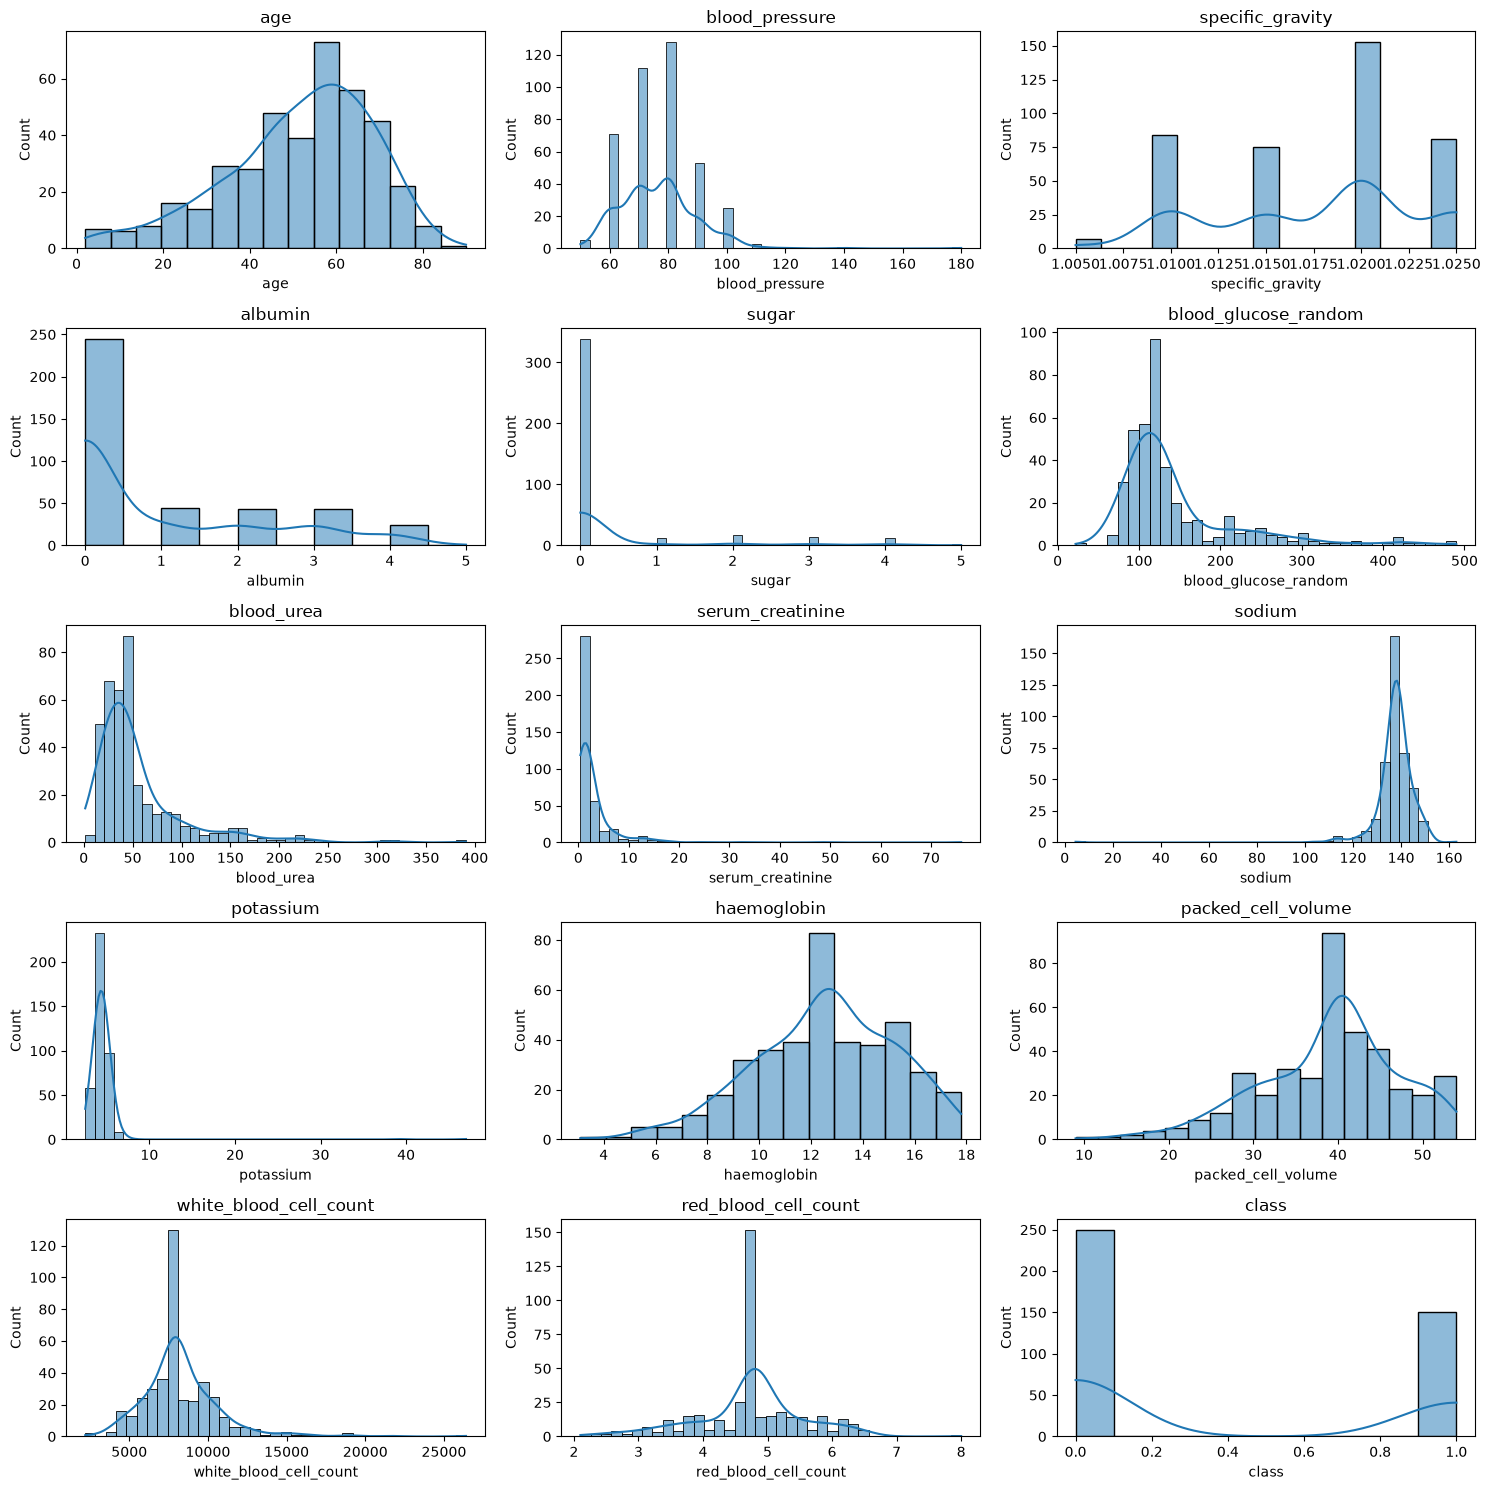

In [35]:
# Distributions of all numerical features

plt.figure(figsize=(15,15))

for i, col in enumerate(num_cols, 1):
    plt.subplot(5, 3, i)   # 15 plots
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

**Observation:**
- `age` is slightly right-skewed, with most patients between 40–70 years.
- `blood_urea` and `serum_creatinine` are strongly right-skewed with characteristic of kidney disease markers where a small number of patients have critically elevated values.
- `haemoglobin` and `packed_cell_volume` show bimodal-like distributions, likely reflecting the CKD vs non-CKD separation. CKD patients tend to have lower values.
- `blood_glucose_random` shows high variance, consistent with the co-occurrence of diabetes in CKD patients.


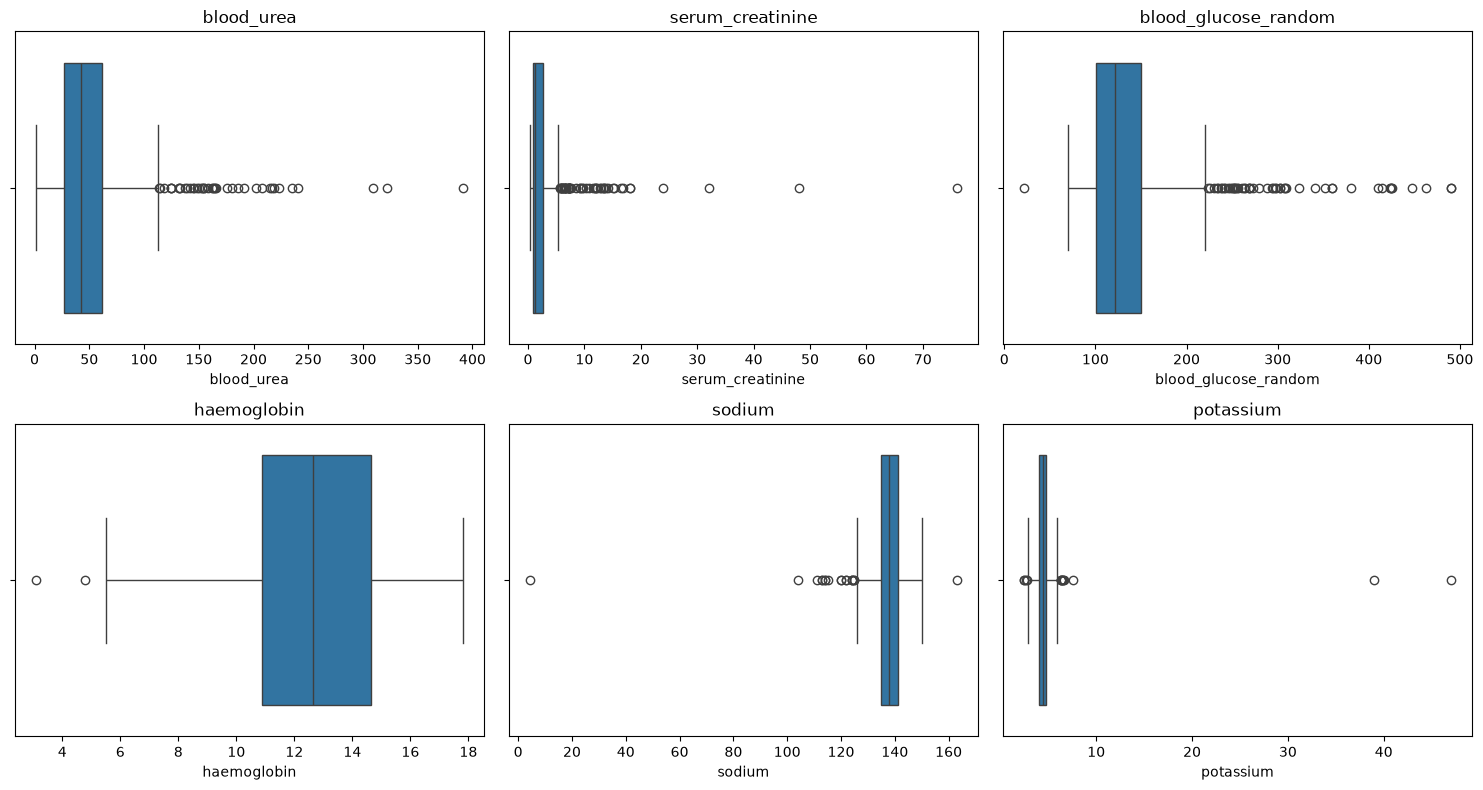

In [36]:
#key clinical markers
key_num = ['blood_urea', 'serum_creatinine', 'blood_glucose_random',
           'haemoglobin', 'sodium', 'potassium']

plt.figure(figsize=(15,8))

for i, col in enumerate(key_num, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


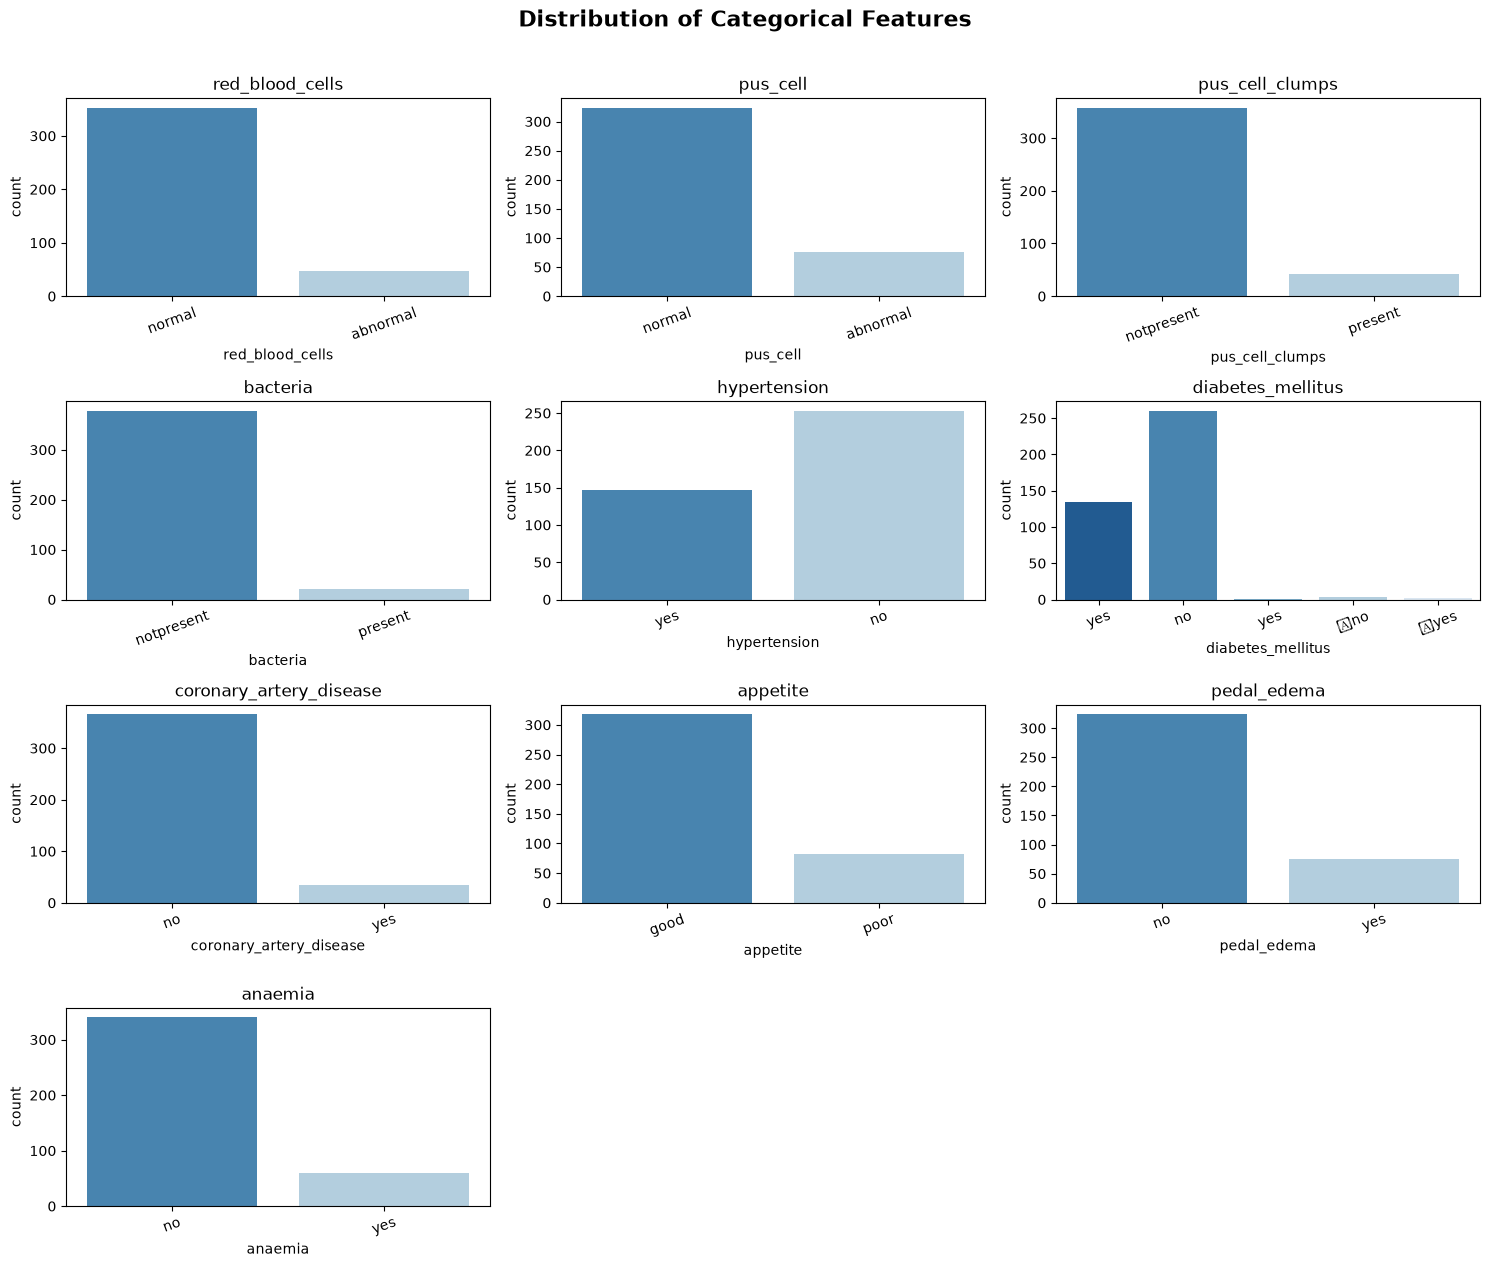

In [37]:
# Count plots for all categorical features
plt.figure(figsize=(15,15))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(5, 3, i)
    sns.countplot(data=df, x=col, palette='Blues_r')
    plt.title(col)
    plt.xticks(rotation=20)

plt.suptitle('Distribution of Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Observation:**
- Most patients show abnormal `pus_cell` readings, which is a direct CKD indicator.
- `hypertension` is present in a significant portion of patients which is consistent with clinical literature linking hypertension to CKD progression.
- `diabetes_mellitus` and `coronary_artery_disease` co-occurrence highlights that CKD patients tend to carry multiple comorbidities.
- The majority of patients report poor `appetite`, which is a common symptom in advanced CKD stages.


### Bivariate Analysis- Feature vs CKD Status
**Hypotheses being tested:**
1. CKD patients will show higher blood urea and serum creatinine.
2. CKD patients will have lower haemoglobin and packed cell volume (anaemia link).
3. Hypertension and diabetes mellitus will be disproportionately present in CKD patients.
4. Blood pressure will be elevated in CKD patients.
5. Older patients will show higher CKD prevalence.

---


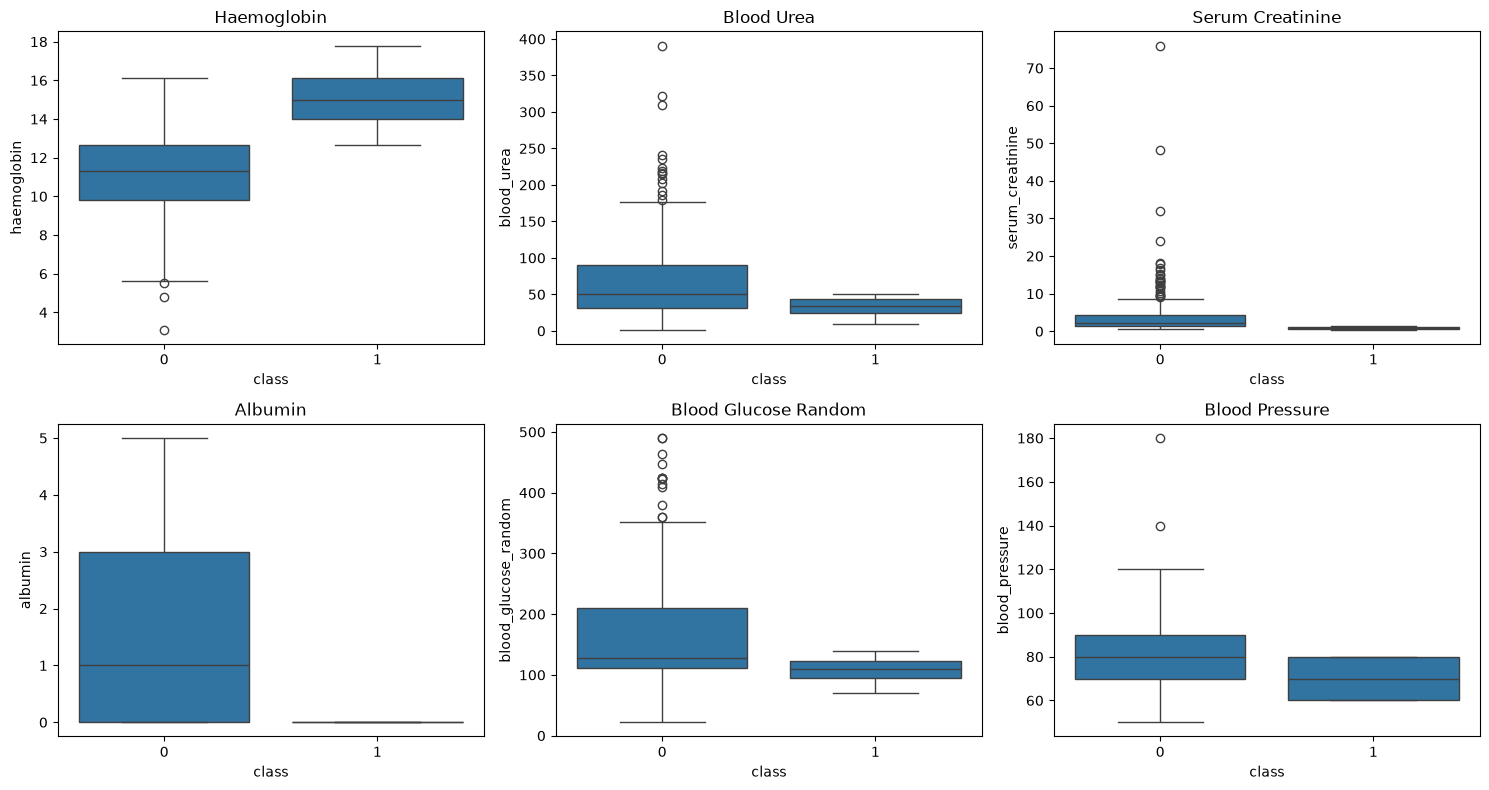

In [38]:
key_features = ['haemoglobin', 'blood_urea', 'serum_creatinine',
                'albumin', 'blood_glucose_random', 'blood_pressure']

plt.figure(figsize=(15,8))

for i, col in enumerate(key_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x='class', y=col)
    plt.title(col.replace('_', ' ').title())

plt.tight_layout()
plt.show()


<Axes: xlabel='age', ylabel='blood_pressure'>

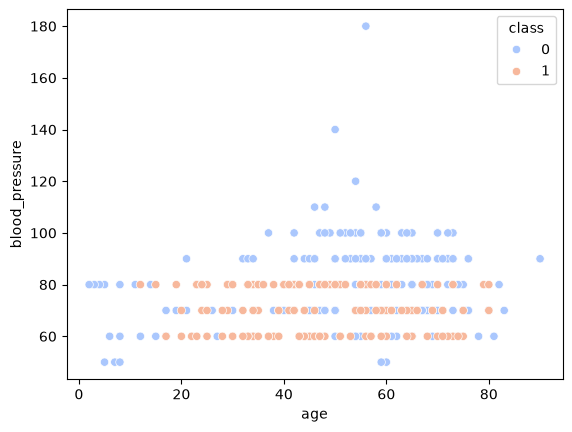

In [39]:
sns.scatterplot(x = 'age', y = 'blood_pressure', data = df, hue = 'class', palette = 'coolwarm')


<Axes: xlabel='diabetes_mellitus', ylabel='albumin'>

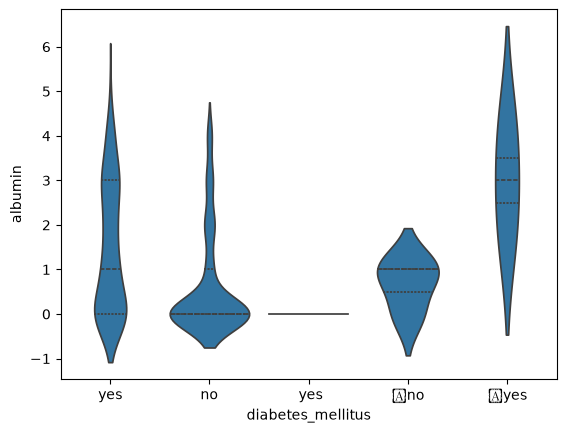

In [40]:
sns.violinplot(x = 'diabetes_mellitus', y = 'albumin', data =df, inner= 'quartile')


<Axes: xlabel='diabetes_mellitus'>

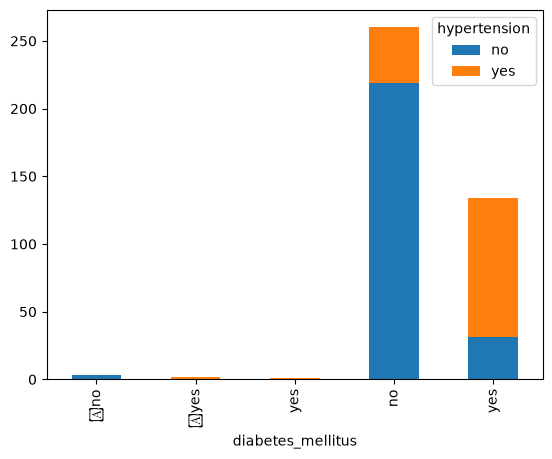

In [41]:
#stacked bar chart
diabetes_hypertension = pd.crosstab(df['diabetes_mellitus'], df['hypertension'])

diabetes_hypertension.plot(kind = 'bar', stacked = True)


In [42]:
# Print median comparison table
for col in key_features:
    ckd = df[df['class'] == 0][col].median()
    non_ckd = df[df['class'] == 1][col].median()

    print(f"{col}: CKD = {ckd:.2f}, Non-CKD = {non_ckd:.2f}")


haemoglobin: CKD = 11.30, Non-CKD = 15.00
blood_urea: CKD = 51.00, Non-CKD = 33.50
serum_creatinine: CKD = 2.20, Non-CKD = 0.90
albumin: CKD = 1.00, Non-CKD = 0.00
blood_glucose_random: CKD = 127.50, Non-CKD = 109.00
blood_pressure: CKD = 80.00, Non-CKD = 70.00


**Finding- Clinical Marker Differences:**
- `haemoglobin` is markedly lower in CKD patients, confirming the well-known CKD-anaemia link.
- `blood_urea` and `serum_creatinine` are substantially elevated in CKD patients — these are primary markers of impaired kidney filtration.
- `albumin` levels are higher in CKD patients, reflecting proteinuria(protein leaking into urine).
- `blood_pressure` is elevated in CKD patients, consistent with hypertension as both a cause and consequence of CKD.
- The separation in these markers is strong enough to suggest they will be highly predictive features in a classification model.


### Multivariate Analysis


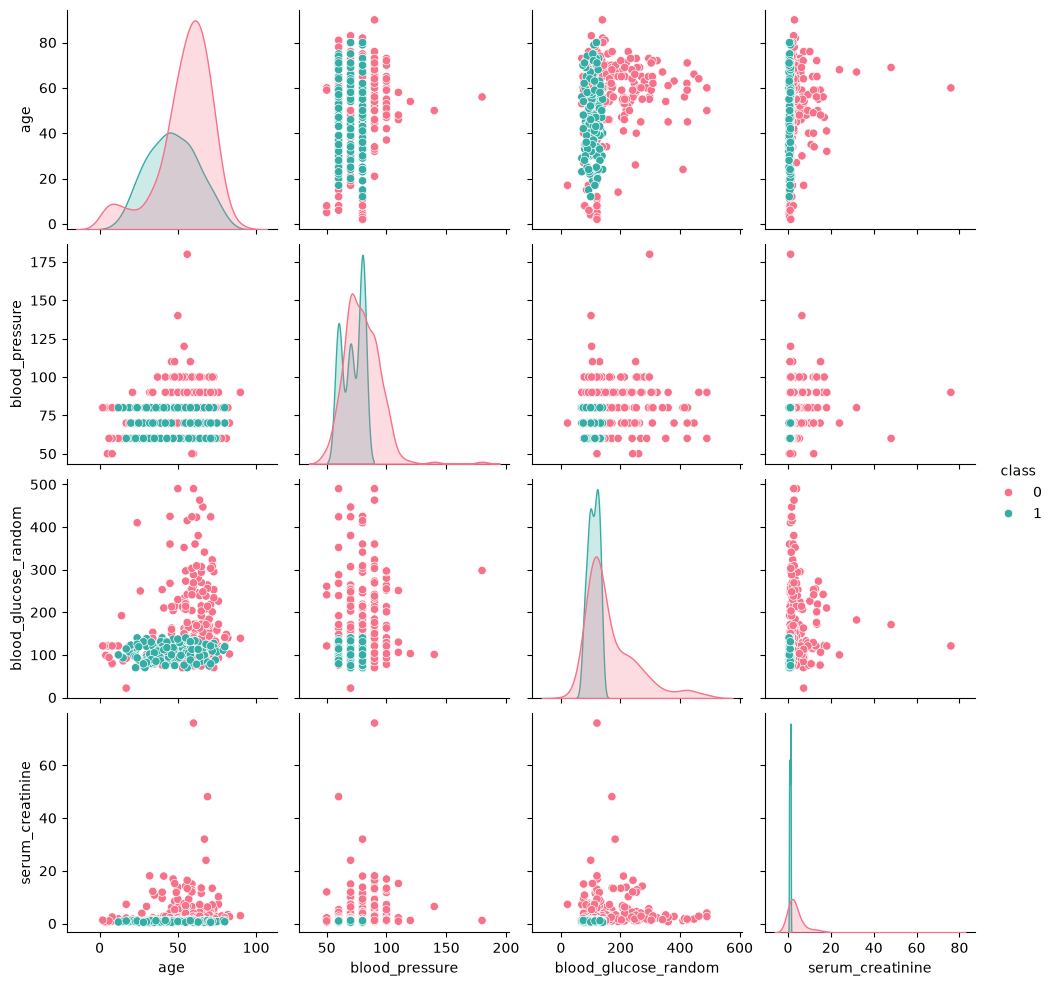

In [43]:
cols = ['age', 'blood_pressure', 'blood_glucose_random', 'serum_creatinine', 'class']
sns.pairplot(df[cols], hue = 'class', palette = 'husl')


<Axes: >

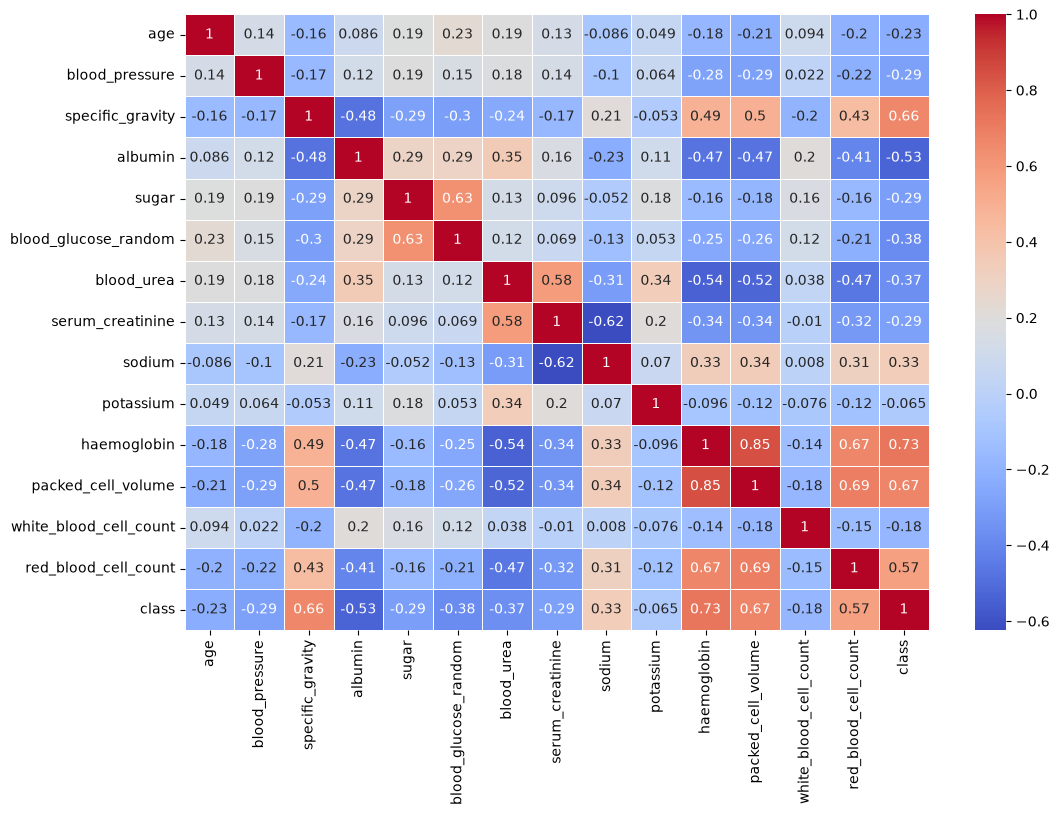

In [44]:
corr = df.corr(numeric_only=True)
plt.figure(figsize = (12, 8))
sns.heatmap(corr, annot = True, cmap = 'coolwarm', linewidth = .5)


<Axes: xlabel='diabetes_mellitus', ylabel='age'>

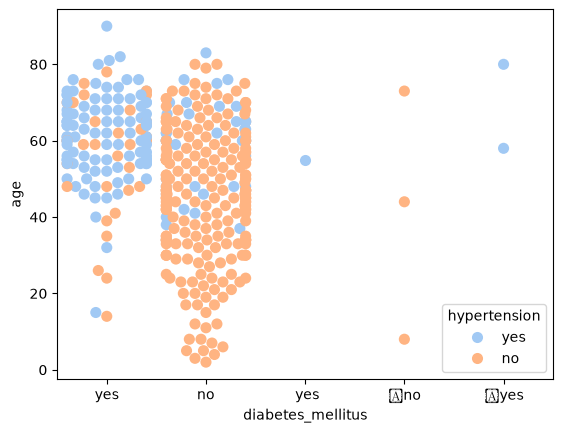

In [45]:
sns.swarmplot(x='diabetes_mellitus', y='age', hue='hypertension', data=df, palette='pastel', size=8)


In [46]:
fig = px.scatter(df, x = 'age', y = 'blood_pressure', color = 'class', hover_data = ['serum_creatinine', 'haemoglobin'],title = "interactive scatterplot with hover information")
fig.show()


In [47]:
fig = px.scatter_3d(df, x = 'age', y = 'blood_pressure',z = 'serum_creatinine', color = 'class', title = "3d scatter plot scatterplot")
fig.show()


In [48]:
data_corr = df.corr(numeric_only = True)
fig = go.Figure(data =go.Heatmap(z = data_corr.values,
                          x = data_corr.columns,
                          y=data_corr.index))
fig.show()


In [49]:
fig = px.scatter_3d(df, x='age', y='blood_pressure', z='serum_creatinine', color='haemoglobin',
                    title='3D Scatter plot with Color Gradient')
fig.show()


**Observation- Correlations:**
- `haemoglobin`, `packed_cell_volume`, and `red_blood_cell_count` are the strongest positive correlates with non-CKD status (i.e., higher values → less likely to have CKD).
- `serum_creatinine`, `blood_urea`, and `albumin` are the strongest negative correlates (i.e., higher values → more likely to have CKD).
- The high correlation between `haemoglobin`, `packed_cell_volume`, and `red_blood_cell_count` is expected as they all measure aspects of red blood cell presence, and are clinically interrelated.
- These findings confirm that haematological and renal filtration markers are the most discriminating features for CKD classification.


In [50]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anaemia,class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,4,0,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,3,0,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,4,0,1,0,1,0
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,3,0,1,1,1,0
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,3,0,0,0,0,0


In [51]:
X = df.drop('class', axis = 1)
y = df['class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (400, 24)
Target shape: (400,)


### Summary & Clinical Insights

### Dataset Overview
This analysis examined **400 patients** with **25 clinical features**. After cleaning, **250 CKD patients** and **150 non-CKD patients** were retained a 62:38 split requiring class-aware modelling strategies.

### Key Clinical Findings

| Finding | Evidence |
|---|---|
| Haemoglobin is the strongest CKD discriminator | Median ~10 g in CKD vs ~15 g in non-CKD |
| Serum creatinine and blood urea confirm impaired kidney filtration | Both significantly elevated in CKD patients |
| Hypertension and diabetes are dominant comorbidities | Strongly overrepresented in CKD group |
| Anaemia is nearly exclusive to CKD patients | Near-complete separation in crosstab |
| Age alone is not a clean discriminator | Distributions overlap significantly |
| Haematological markers cluster strongly together | High correlation between haemoglobin, PCV, RBC |

### Hypothesis Results

| Hypothesis | Result |
|---|---|
| H1: CKD patients show higher blood urea and serum creatinine | Confirmed |
| H2: CKD patients show lower haemoglobin and packed cell volume | Confirmed |
| H3: Hypertension and diabetes disproportionate in CKD | Confirmed |
| H4: Blood pressure elevated in CKD patients | Confirmed |
| H5: Older patients show higher CKD prevalence | Partially Confirmed- CKD patients have higher median age, but distributions overlap substantially |

### Recommended Features for Classification Model
Based on correlation strength and visual separation:

**High priority:** `haemoglobin`, `packed_cell_volume`, `serum_creatinine`, `blood_urea`, `red_blood_cell_count`  
**Medium priority:** `albumin`, `blood_glucose_random`, `hypertension`, `diabetes_mellitus`, `anaemia`  
**Lower priority:** `potassium`, `sodium`, `coronary_artery_disease`

### Next Steps
- Train baseline Logistic Regression classifier
- Compare with Random Forest and XGBoost
- Use stratified train-test split (80:20) to preserve class ratio
